In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
csv_path = "data/heart.csv"

df = pd.read_csv(csv_path)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [30]:
df.shape

(918, 12)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [32]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [33]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

### Checking null values

In [34]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### making graphs for representations

In [35]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove('HeartDisease')  # Remove the target variable from the list of numeric columns
numeric_columns

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

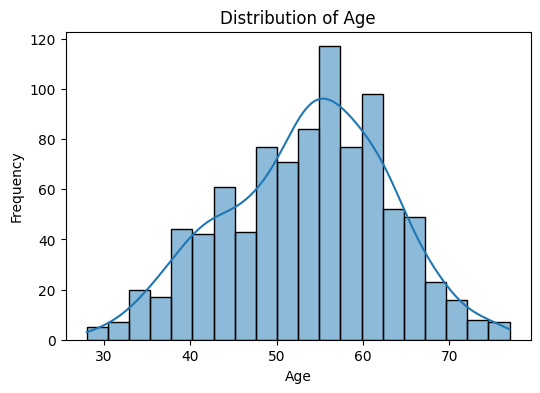

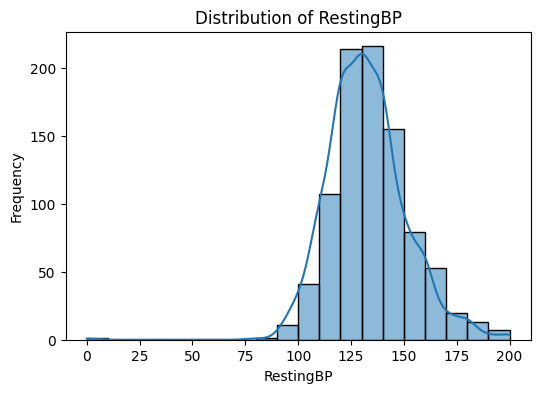

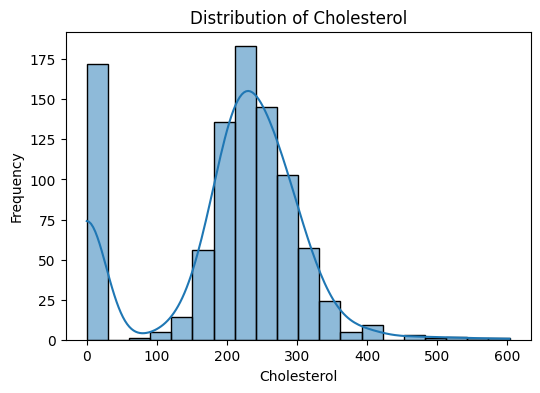

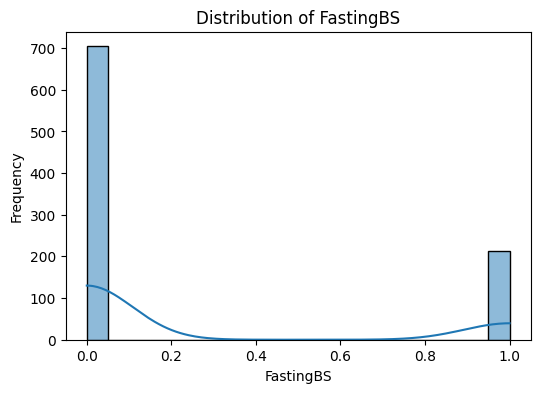

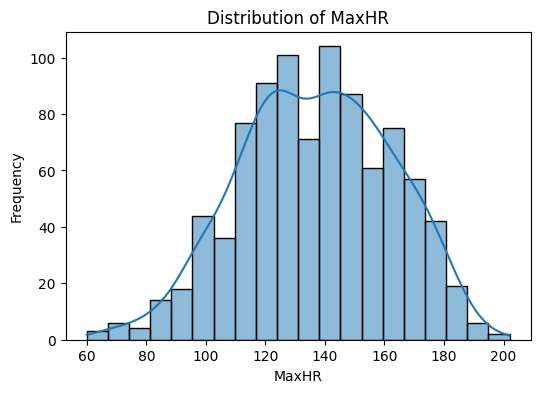

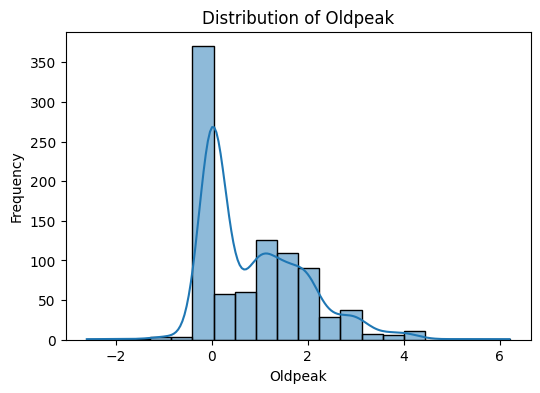

In [36]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

#### checking outliers

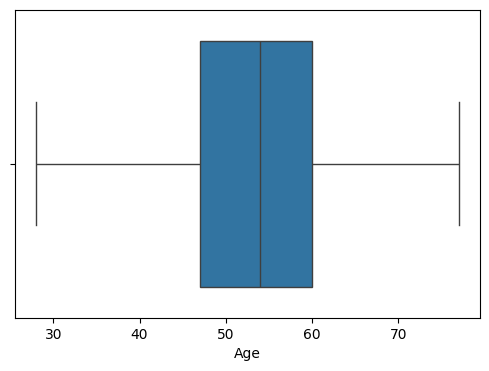

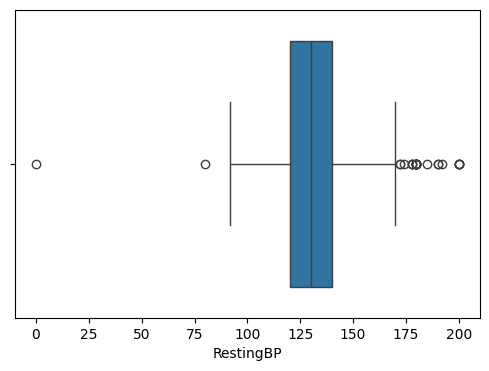

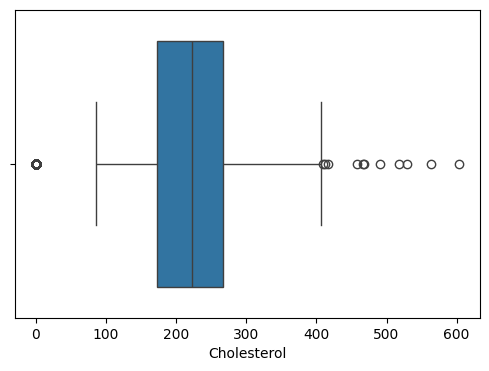

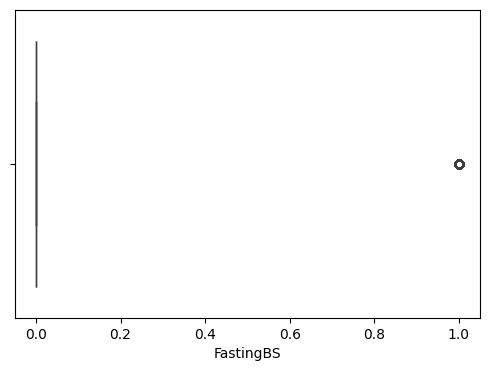

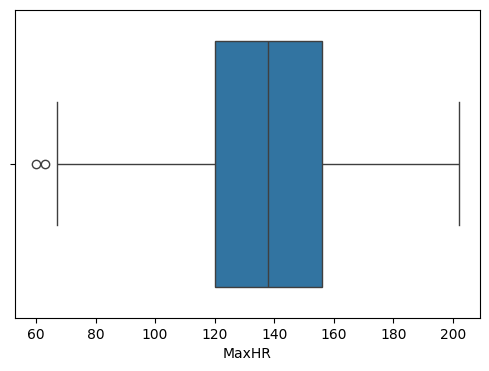

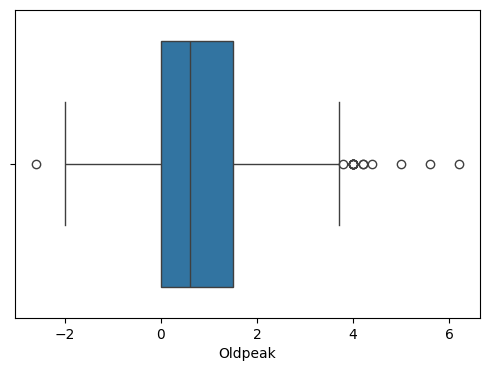

In [37]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

#### Checking Duplicates

In [38]:
df.duplicated().sum()

0

In [39]:
df_cleaned =  df.copy()
df_cleaned = df_cleaned.drop_duplicates()
df_cleaned.shape

(918, 12)

### Checking if data is equally distributed

In [40]:
df_cleaned['HeartDisease'].value_counts()   ## yep it is

HeartDisease
1    508
0    410
Name: count, dtype: int64

## Making plots

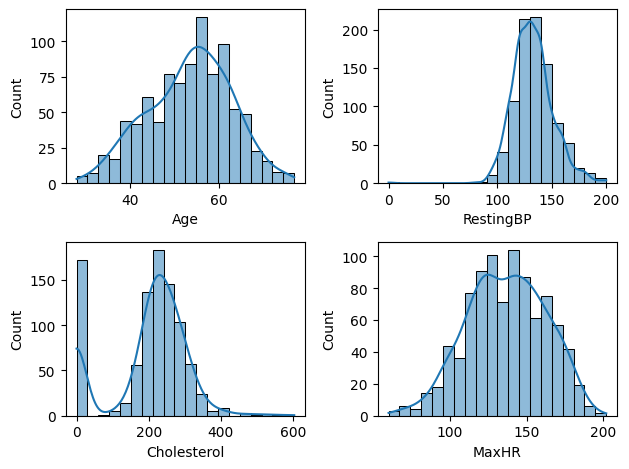

In [41]:
def plotting(var , num):
    plt.subplot(2,2,num)
    sns.histplot(df_cleaned[var], kde=True, bins=20)

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)  
plotting('MaxHR', 4)

plt.tight_layout()

there is a person with 0  resting bp -- untrue cannot be 

0 cholesstrrol -- impossible

In [42]:
## take cholestrol mean and replace the 0 values with it
cholesterol_mean = df_cleaned.loc[df_cleaned['Cholesterol'] != 0, 'Cholesterol'].mean().round(2)
df_cleaned['Cholesterol'] = df_cleaned['Cholesterol'].replace(0, cholesterol_mean)

<Axes: xlabel='Cholesterol', ylabel='Count'>

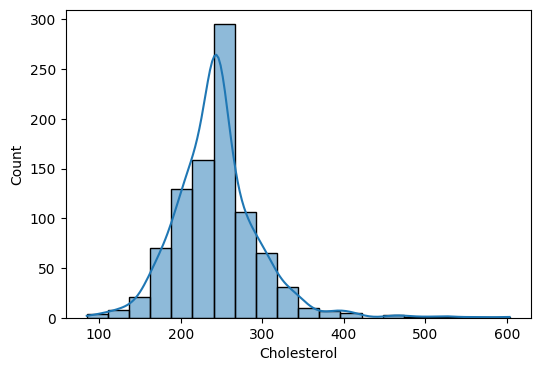

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['Cholesterol'], kde=True, bins=20)

In [44]:
## do same with resting bp
restingbp_mean = df_cleaned.loc[df_cleaned['RestingBP'] != 0, 'RestingBP'].mean().round(2)
df_cleaned['RestingBP'] = df_cleaned['RestingBP'].replace(0, restingbp_mean)

<Axes: xlabel='Cholesterol', ylabel='Count'>

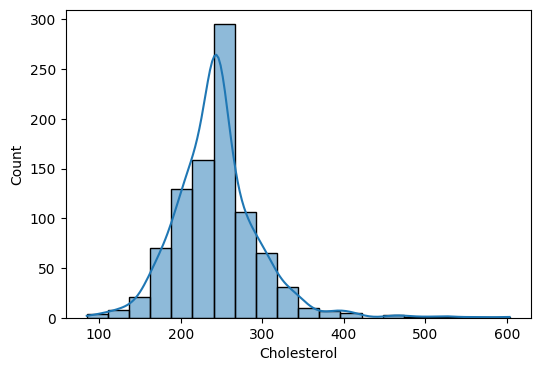

In [45]:
plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['Cholesterol'], kde=True, bins=20)

////

<Axes: xlabel='Sex', ylabel='count'>

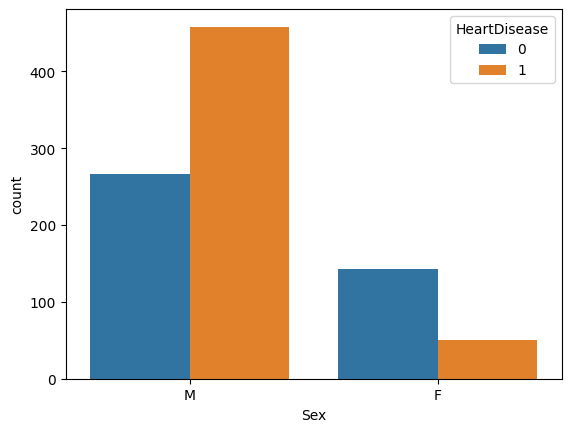

In [48]:
sns.countplot(x='Sex', data=df_cleaned , hue='HeartDisease')   # anamoly

<Axes: xlabel='ChestPainType', ylabel='count'>

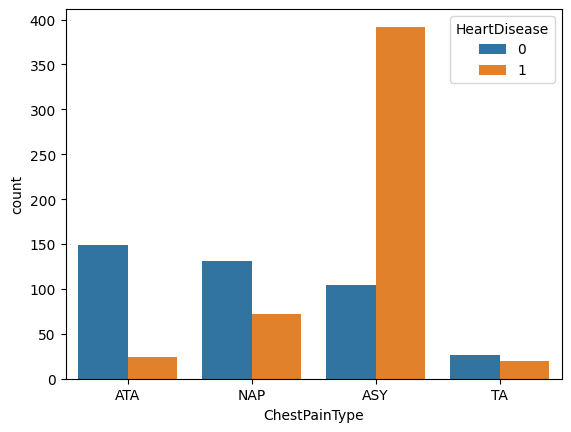

In [47]:
sns.countplot(x='ChestPainType', data=df_cleaned, hue='HeartDisease')   # anamoly

<Axes: xlabel='HeartDisease', ylabel='Age'>

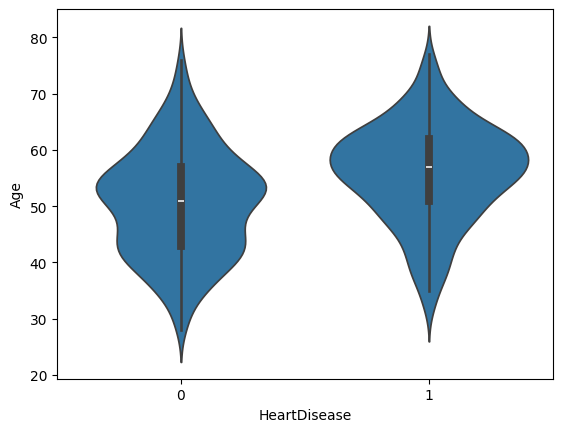

In [50]:
sns.violinplot(x='HeartDisease', y='Age', data=df_cleaned)   # anamoly

### HEatmap

<Axes: >

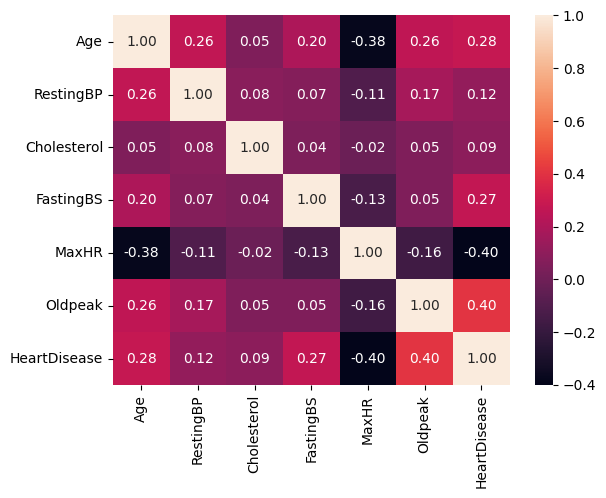

In [53]:
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True,  fmt=".2f")

### Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded = df_cleaned.copy()